In [41]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

import numpy as np
import tensorflow as tf

from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras import Sequential

### 원본 이미지를 다양하게 변형하여 좀더 잘 분류하기 위한 목적

Keras의 `ImageDataGenerator`는 딥러닝 모델의 성능을 높이기 위해 **데이터 증강(Data Augmentation)**을 수행하는 아주 유용한 도구

---

### 1. 전처리 및 정규화

* **`rescale=1./255`**: 이미지의 각 픽셀 값은 보통 0~255 사이의 정수입니다. 이를 로 곱하여 **0과 1 사이의 실수 값**으로 변환합니다. 모델이 학습할 때 값이 너무 크면 계산 효율이 떨어지기 때문에 필수적으로 사용하는 과정입니다.

### 2. 반전 및 회전 (방향성)

* **`horizontal_flip=True`**: 이미지를 좌우로 뒤집습니다. (거울 모드)
* **`vertical_flip=True`**: 이미지를 상하로 뒤집습니다.
> **주의**: 풍경이나 일반 사물 데이터에서는 상하 반전이 비현실적일 수 있지만, 위성 사진이나 의료 영상(세포 등) 분석에는 유용하게 쓰입니다.


* **`rotation_range=30`**: 이미지를 지정된 범위(0~30도) 내에서 무작위로 회전시킵니다.

### 3. 형태 변형 및 이동

* **`shear_range=0.5`**: '전단 변형'이라고 하며, 이미지를 한쪽 방향으로 밀어서 찌그러뜨리는 효과를 줍니다. (사각형을 평행사변형으로 만드는 느낌)
* **`zoom_range=0.2`**: 이미지를 20% 내외로 확대하거나 축소합니다.
* **`width_shift_range=0.1`**: 가로 방향으로 전체 너비의 10% 범위 내에서 이미지를 이동시킵니다.
* **`height_shift_range=0.1`**: 세로 방향으로 전체 높이의 10% 범위 내에서 이미지를 이동시킵니다.

### 4. 색감 및 기타 설정

* **`brightness_range=[0.5, 1.5]`**: 이미지의 밝기를 조절합니다. 0.5는 원래보다 50% 어둡게, 1.5는 50% 밝게 만드는 범위 내에서 무작위로 적용됩니다.
* **`fill_mode='nearest'`**: 이미지를 회전시키거나 이동시킬 때 발생하는 **빈 공간을 어떻게 채울지** 결정합니다.
* `nearest`: 가장 가까운 픽셀의 색상으로 빈 공간을 채웁니다. (가장 많이 쓰임)
* 그 외 `constant`(검정색), `reflect`(거울처럼 반사) 등이 있습니다.

---

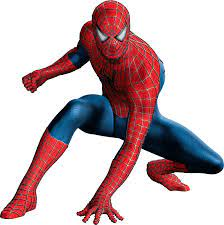

In [42]:
s = load_img( 'image/s.jpg')
s

In [43]:
dataGen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, vertical_flip=True, 
                            shear_range=0.5, 
                            brightness_range=[0.5,1.5], zoom_range=0.2,
                            width_shift_range=0.1, height_shift_range=0.1,
                            rotation_range=30, fill_mode='nearest' )

```python
dataGen = ImageDataGenerator(
    rescale=1./255,            # 픽셀 값 정규화 (필수)
    rotation_range=180,        # 도형은 어느 각도에서나 나올 수 있으므로 범위를 넓게(0~180도)
    width_shift_range=0.1,     # 중심에서 약간 벗어난 경우 대비
    height_shift_range=0.1,    
    shear_range=0.1,           # 너무 크면 사각형이 평행사변형(마름모)이 되어 오답 가능성 있음 (주의)
    zoom_range=0.2,            # 도형의 크기 변화에 대응
    horizontal_flip=True,      # 좌우 반전
    vertical_flip=True,        # 상하 반전
    fill_mode='nearest'        # 빈 공간 채우기
)

In [44]:
imgArr = img_to_array(s)
print( imgArr.shape )
imgArr = imgArr.reshape( 1, 225,224,3 )
imgArr.shape

(225, 224, 3)


(1, 225, 224, 3)

In [45]:
imageGen = dataGen.flow( imgArr )

In [46]:
import matplotlib.pyplot as plt

(1, 225, 224, 3)


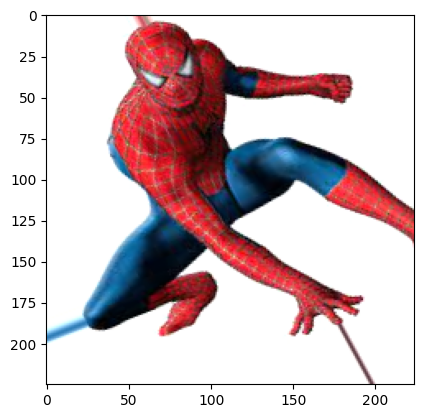

(1, 225, 224, 3)


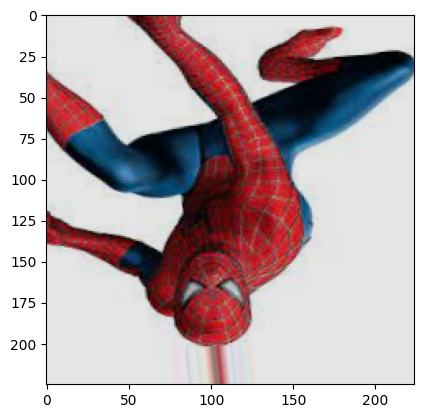

(1, 225, 224, 3)


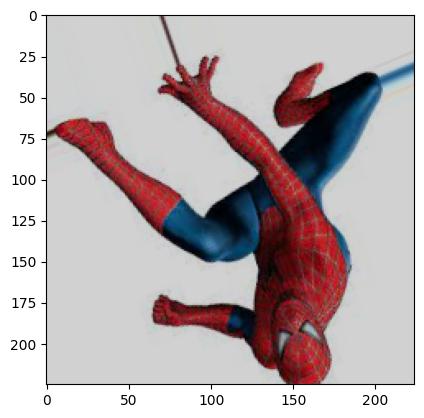

(1, 225, 224, 3)


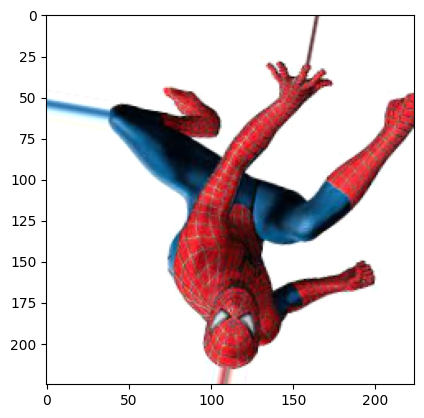

(1, 225, 224, 3)


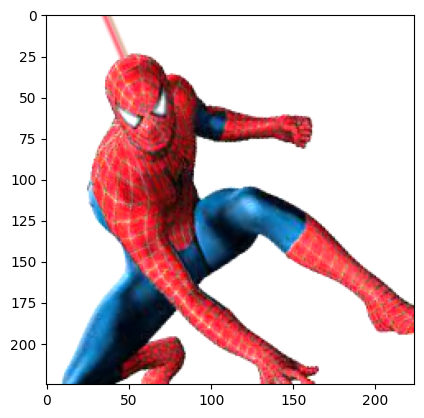

(1, 225, 224, 3)


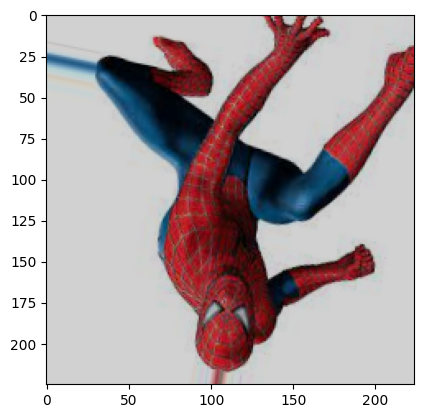

(1, 225, 224, 3)


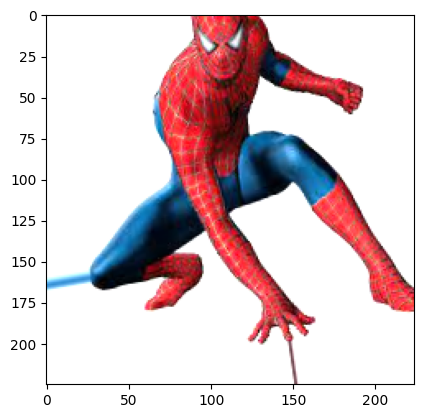

(1, 225, 224, 3)


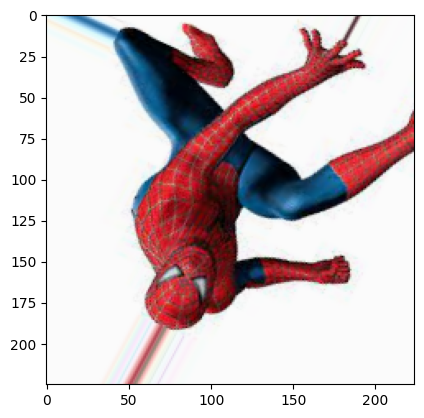

(1, 225, 224, 3)


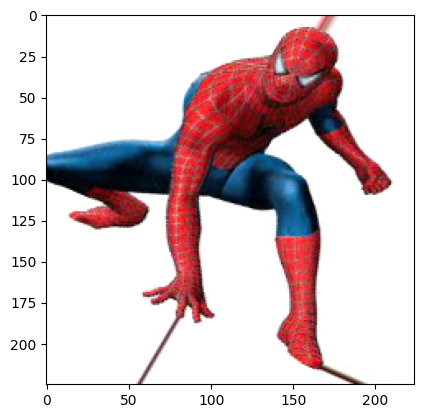

(1, 225, 224, 3)


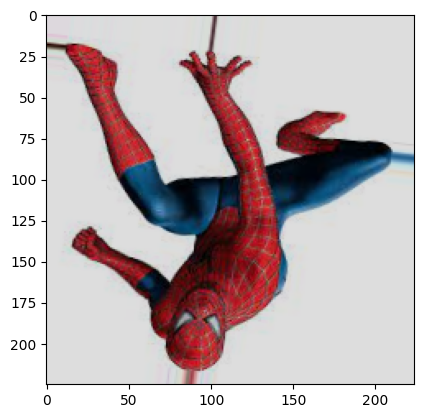

(1, 225, 224, 3)


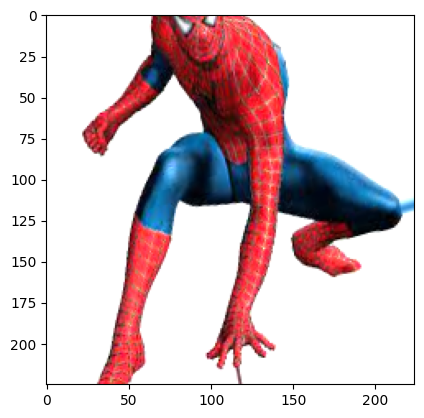

(1, 225, 224, 3)


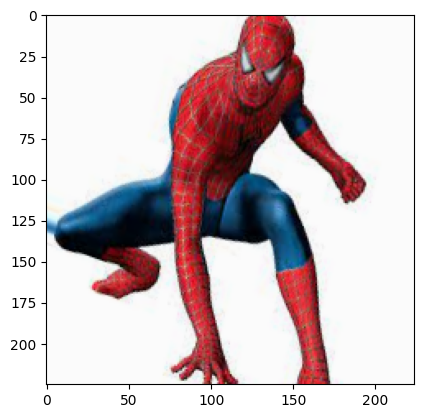

(1, 225, 224, 3)


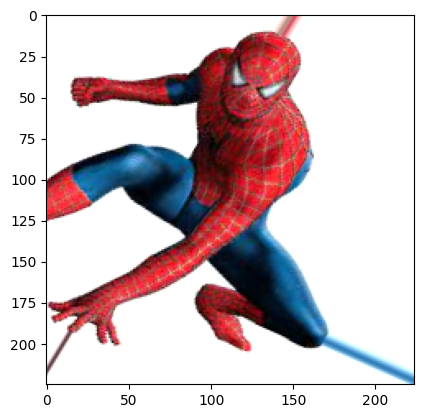

(1, 225, 224, 3)


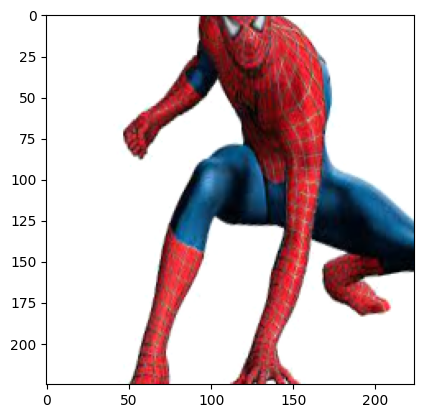

(1, 225, 224, 3)


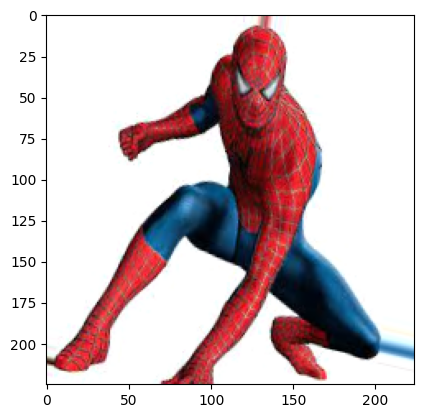

(1, 225, 224, 3)


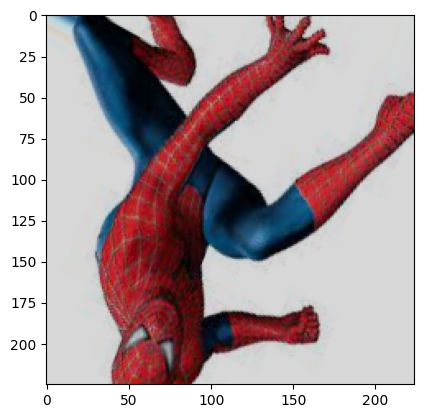

(1, 225, 224, 3)


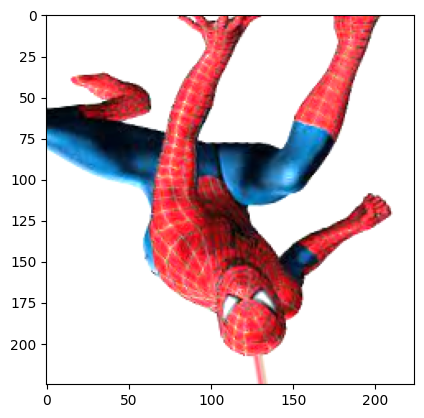

(1, 225, 224, 3)


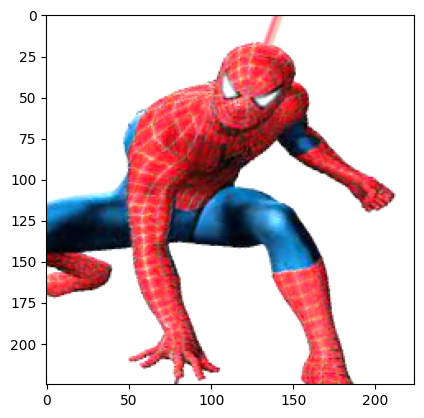

(1, 225, 224, 3)


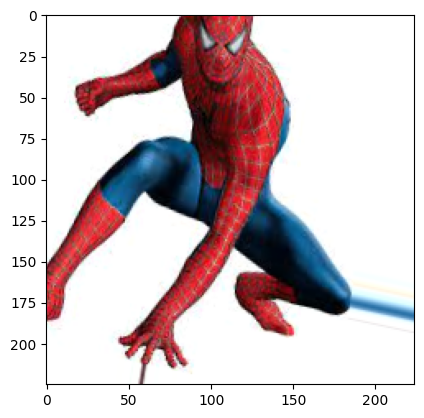

(1, 225, 224, 3)


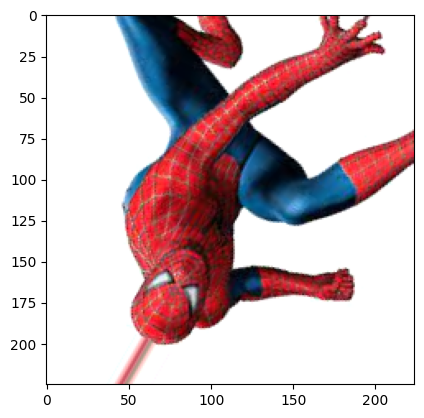

In [47]:
for n in range(20):
    img = next(imageGen)
    print( img.shape ) 
    plt.imshow( img[0] )
    plt.show()

In [48]:
from tensorflow.keras.datasets.fashion_mnist import load_data

In [49]:
imageGen = ImageDataGenerator(rescale = 1./255, horizontal_flip=True, 
                            vertical_flip=True, 
                            shear_range=0.5, 
                            brightness_range=[0.5,1.5], zoom_range=0.2,
                            width_shift_range=0.1, height_shift_range=0.1,
                            rotation_range=30, fill_mode='nearest' )
trainGen = imageGen.flow_from_directory('./shapes', target_size = (98,98))

Found 14970 images belonging to 4 classes.


In [56]:
model = Sequential()
model.add( Conv2D( 32, kernel_size=(3,3), strides=1, input_shape=(98,98,3), 
                    activation='relu', padding='same' ) )
model.add( Conv2D( 64, kernel_size=(3,3), activation='relu') )
model.add( MaxPool2D( pool_size=(2,2 ) ) )
model.add( Flatten()) 
model.add( Dense( units=64, activation='relu'))
model.add( Dense( units=4, activation='softmax'))
model.compile( loss='categorical_crossentropy', optimizer='adam', 
                metrics=['acc'] )
model.fit( trainGen, epochs=5 )

Epoch 1/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 73s 154ms/step - acc: 0.8975 - loss: 0.3139
Epoch 2/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 69s 148ms/step - acc: 0.9870 - loss: 0.0406
Epoch 3/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - acc: 0.9951 - loss: 0.0158
Epoch 4/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 72s 153ms/step - acc: 0.9947 - loss: 0.0174
Epoch 5/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - acc: 0.9963 - loss: 0.0125


In [ ]:
from tensorflow.keras.datasets.fashion_mnist import load_data
from tensorflow.keras.utils import to_categorical

In [ ]:
(x_train, y_train), (x_test, y_test)  = load_data()

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
x_trainR = x_train.reshape( -1,28,28,1)

In [ ]:
y_trainOne = to_categorical( y_train )

In [ ]:
imageGen = ImageDataGenerator(rescale = 1./255, horizontal_flip=True, 
                            vertical_flip=True, 
                            shear_range=0.5, 
                            brightness_range=[0.5,1.5], zoom_range=0.2,
                            width_shift_range=0.1, height_shift_range=0.1,
                            rotation_range=30, fill_mode='nearest' )

In [ ]:
trainGen = imageGen.flow( x_trainR, y_trainOne )

In [ ]:
model = Sequential()
model.add( Conv2D( 32, kernel_size=(3,3), strides=1, input_shape=(28,28,1), 
                    activation='relu', padding='same' ) )
model.add( Conv2D( 64, kernel_size=(3,3), activation='relu') )
model.add( MaxPool2D( pool_size=(2,2 ) ) )
model.add( Flatten()) 
model.add( Dense( units=64, activation='relu'))
model.add( Dense( units=10, activation='softmax'))
model.compile( loss='categorical_crossentropy', optimizer='adam', 
                metrics=['acc'] )
model.fit( trainGen, epochs=5 )

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - acc: 0.6725 - loss: 0.8747
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - acc: 0.7494 - loss: 0.6627
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - acc: 0.7710 - loss: 0.6028
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - acc: 0.7862 - loss: 0.5649
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - acc: 0.7970 - loss: 0.5422
